In [1]:
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import numpy as np
import seaborn as sns

Load in the all the data from the different parameters

In [2]:
# df_list = []
# nes=[100,200,500,1000,1500,1800,2000]
# scenarios = ['bgs','hh','neutral']
# ss = [0.01]
# cs = [1,10,30,100]
# mu_keys = ['high']

# for ne in nes:
#     for scenario in scenarios:
#         for c in cs:
#             for mu_key in mu_keys:
#                 try:
#                     if scenario=='bgs':
#                         file=f'results/analyzed_bgs_ne_{ne}_mu_{mu_key}_c_{c}.csv'
#                         df = pd.read_csv(file)
#                         df_list.append(df)
#                     elif scenario=='neutral':
#                         file=f'results/analyzed_neutral_ne_{ne}_mu_{mu_key}_c_{c}.csv'
#                         df = pd.read_csv(file)
#                         df_list.append(df)
#                     else:
#                         for s in ss:
#                             file=f'results/analyzed_hh_ne_{ne}_s_{s}_mu_{mu_key}_c_{c}.csv'
#                             df = pd.read_csv(file)
#                             df_list.append(df)
#                 except:
#                     continue
# concat = pd.concat(df_list)
# concat = concat.reset_index()
# concat.to_csv('results/concat_simulations.csv', index=False)



In [3]:
concat = pd.read_csv('results/concat_simulations.csv')
grouped_df = concat.groupby(['scenario','ne','s', 'mu_key', 'c'], dropna=False)

## Supplementary figures 

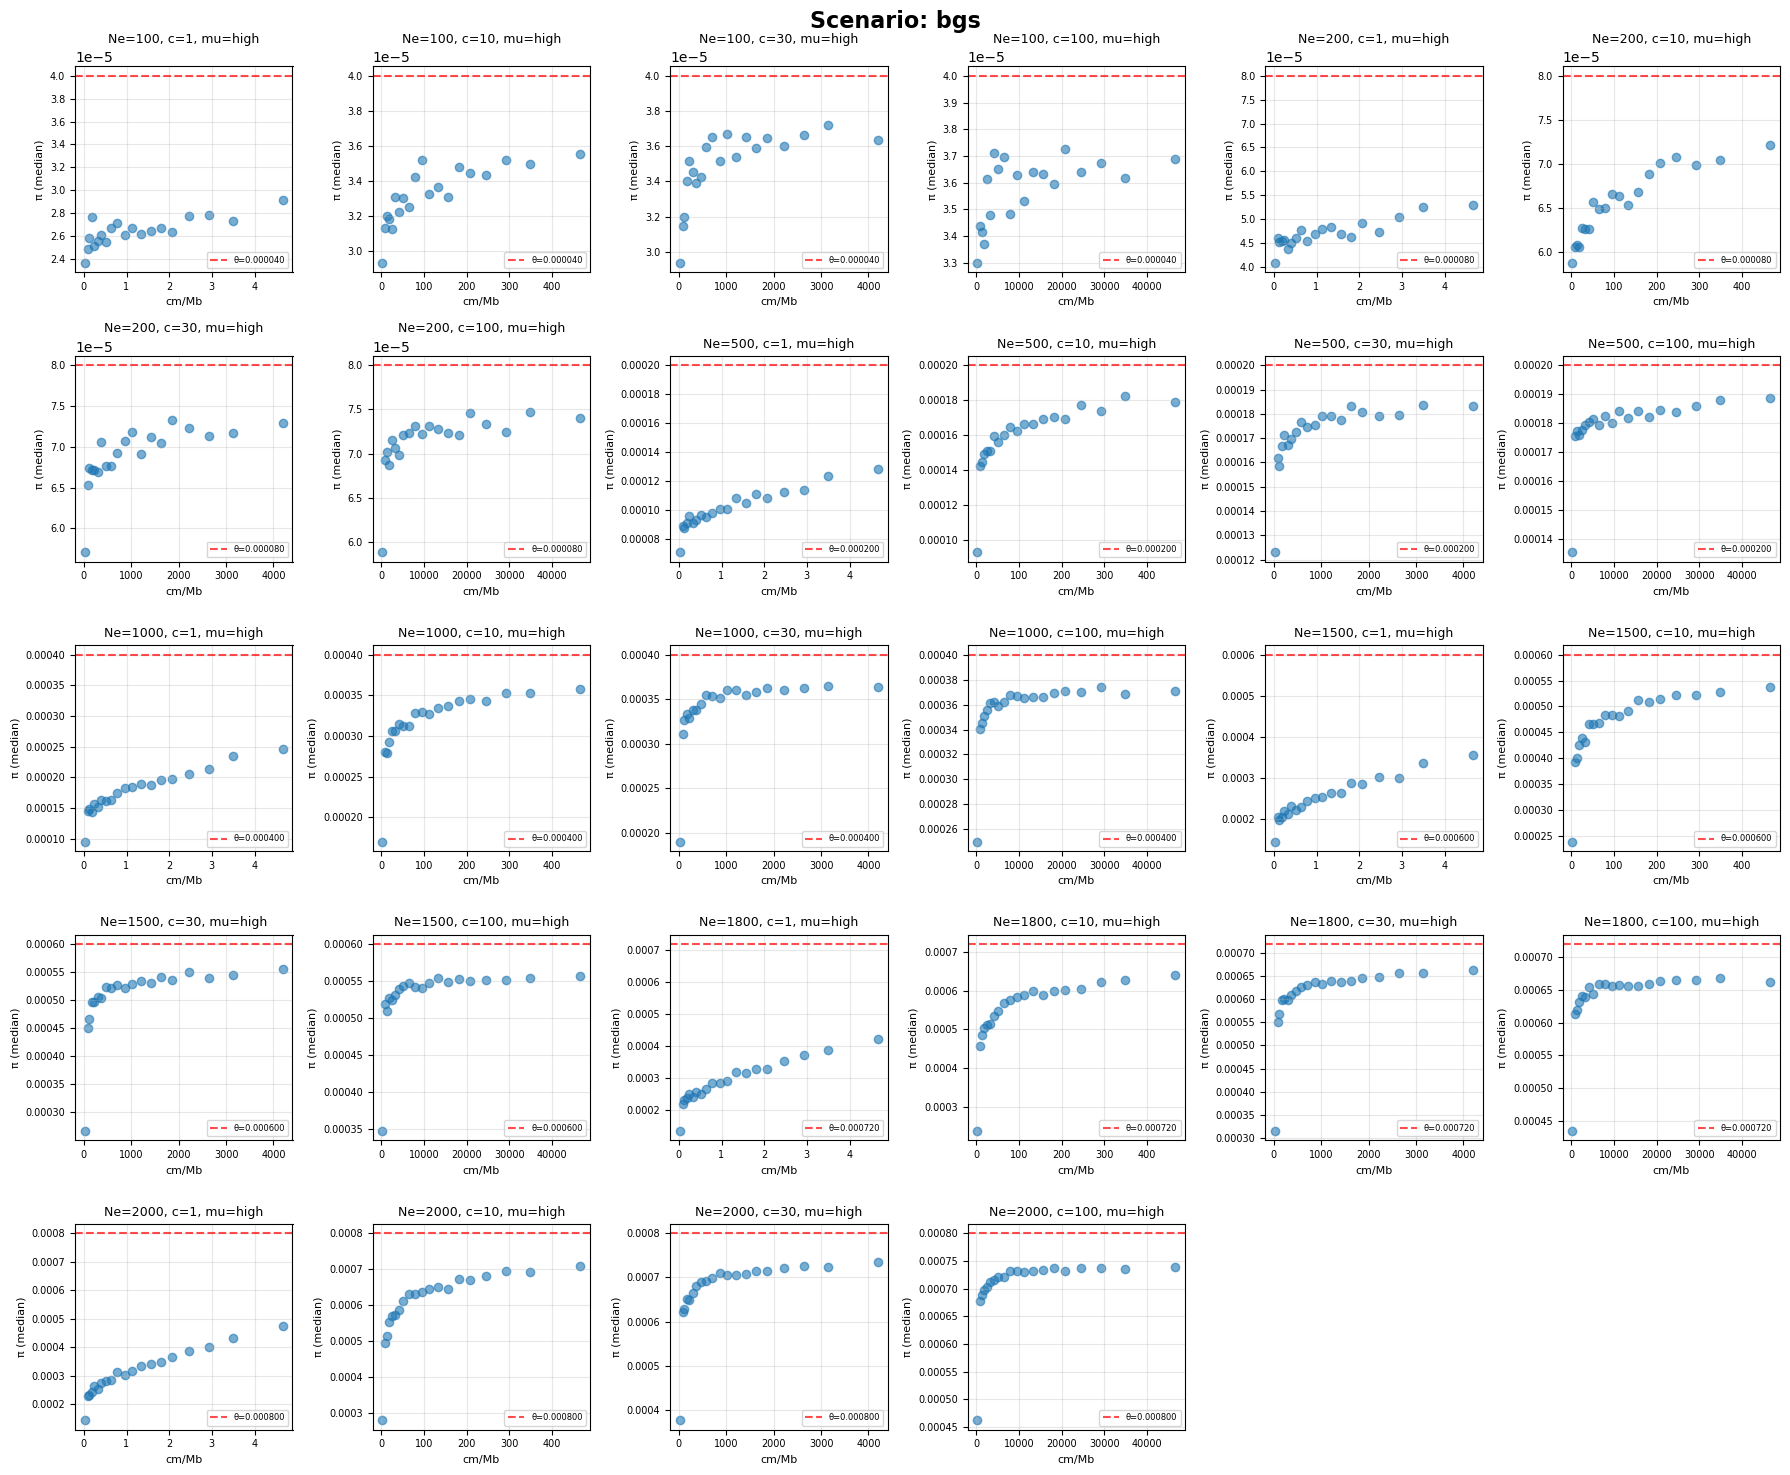

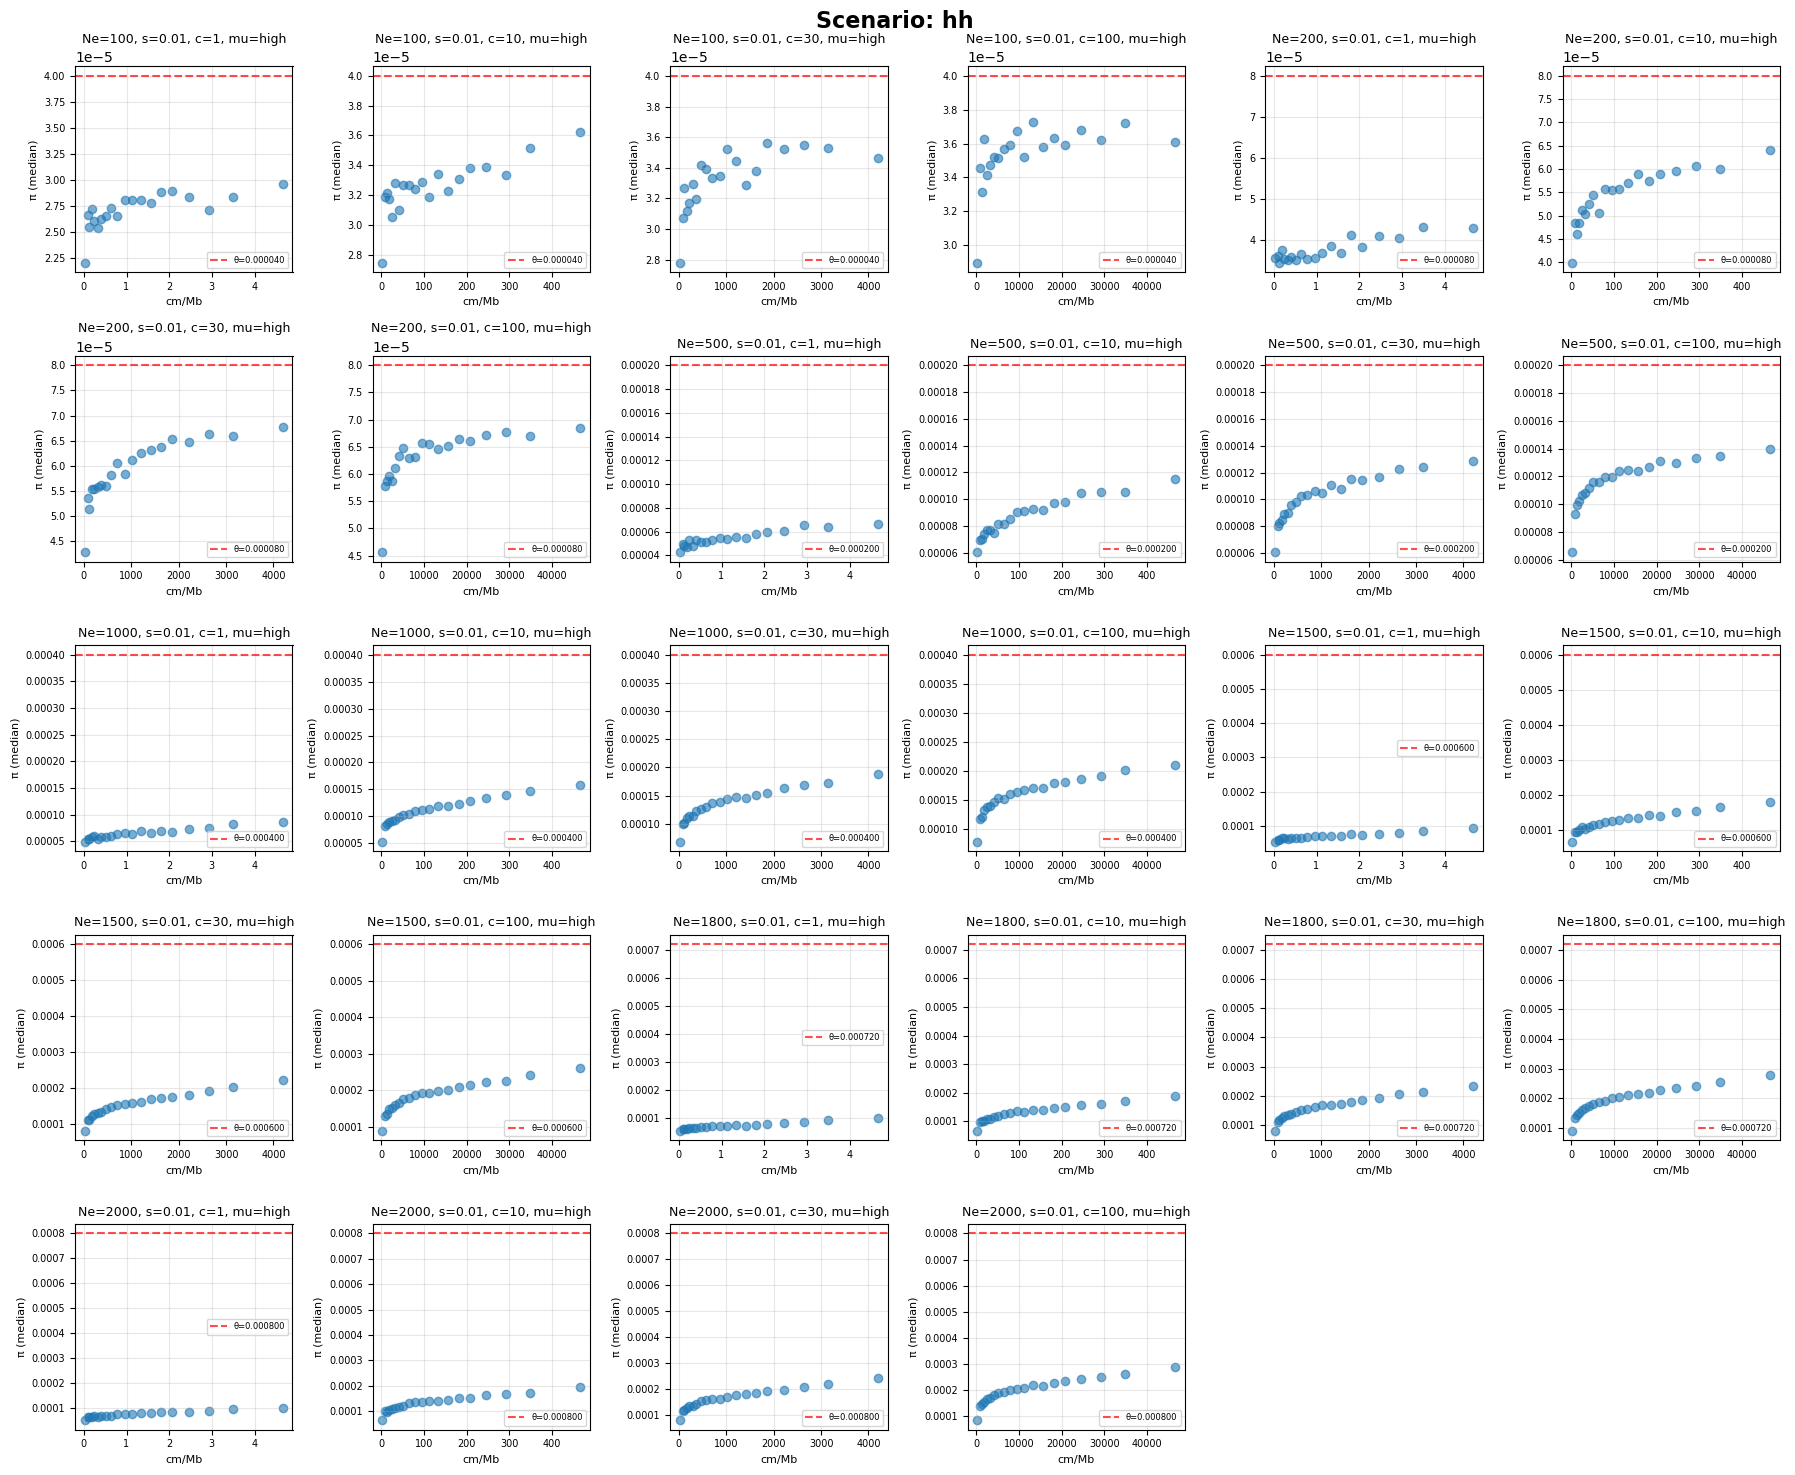

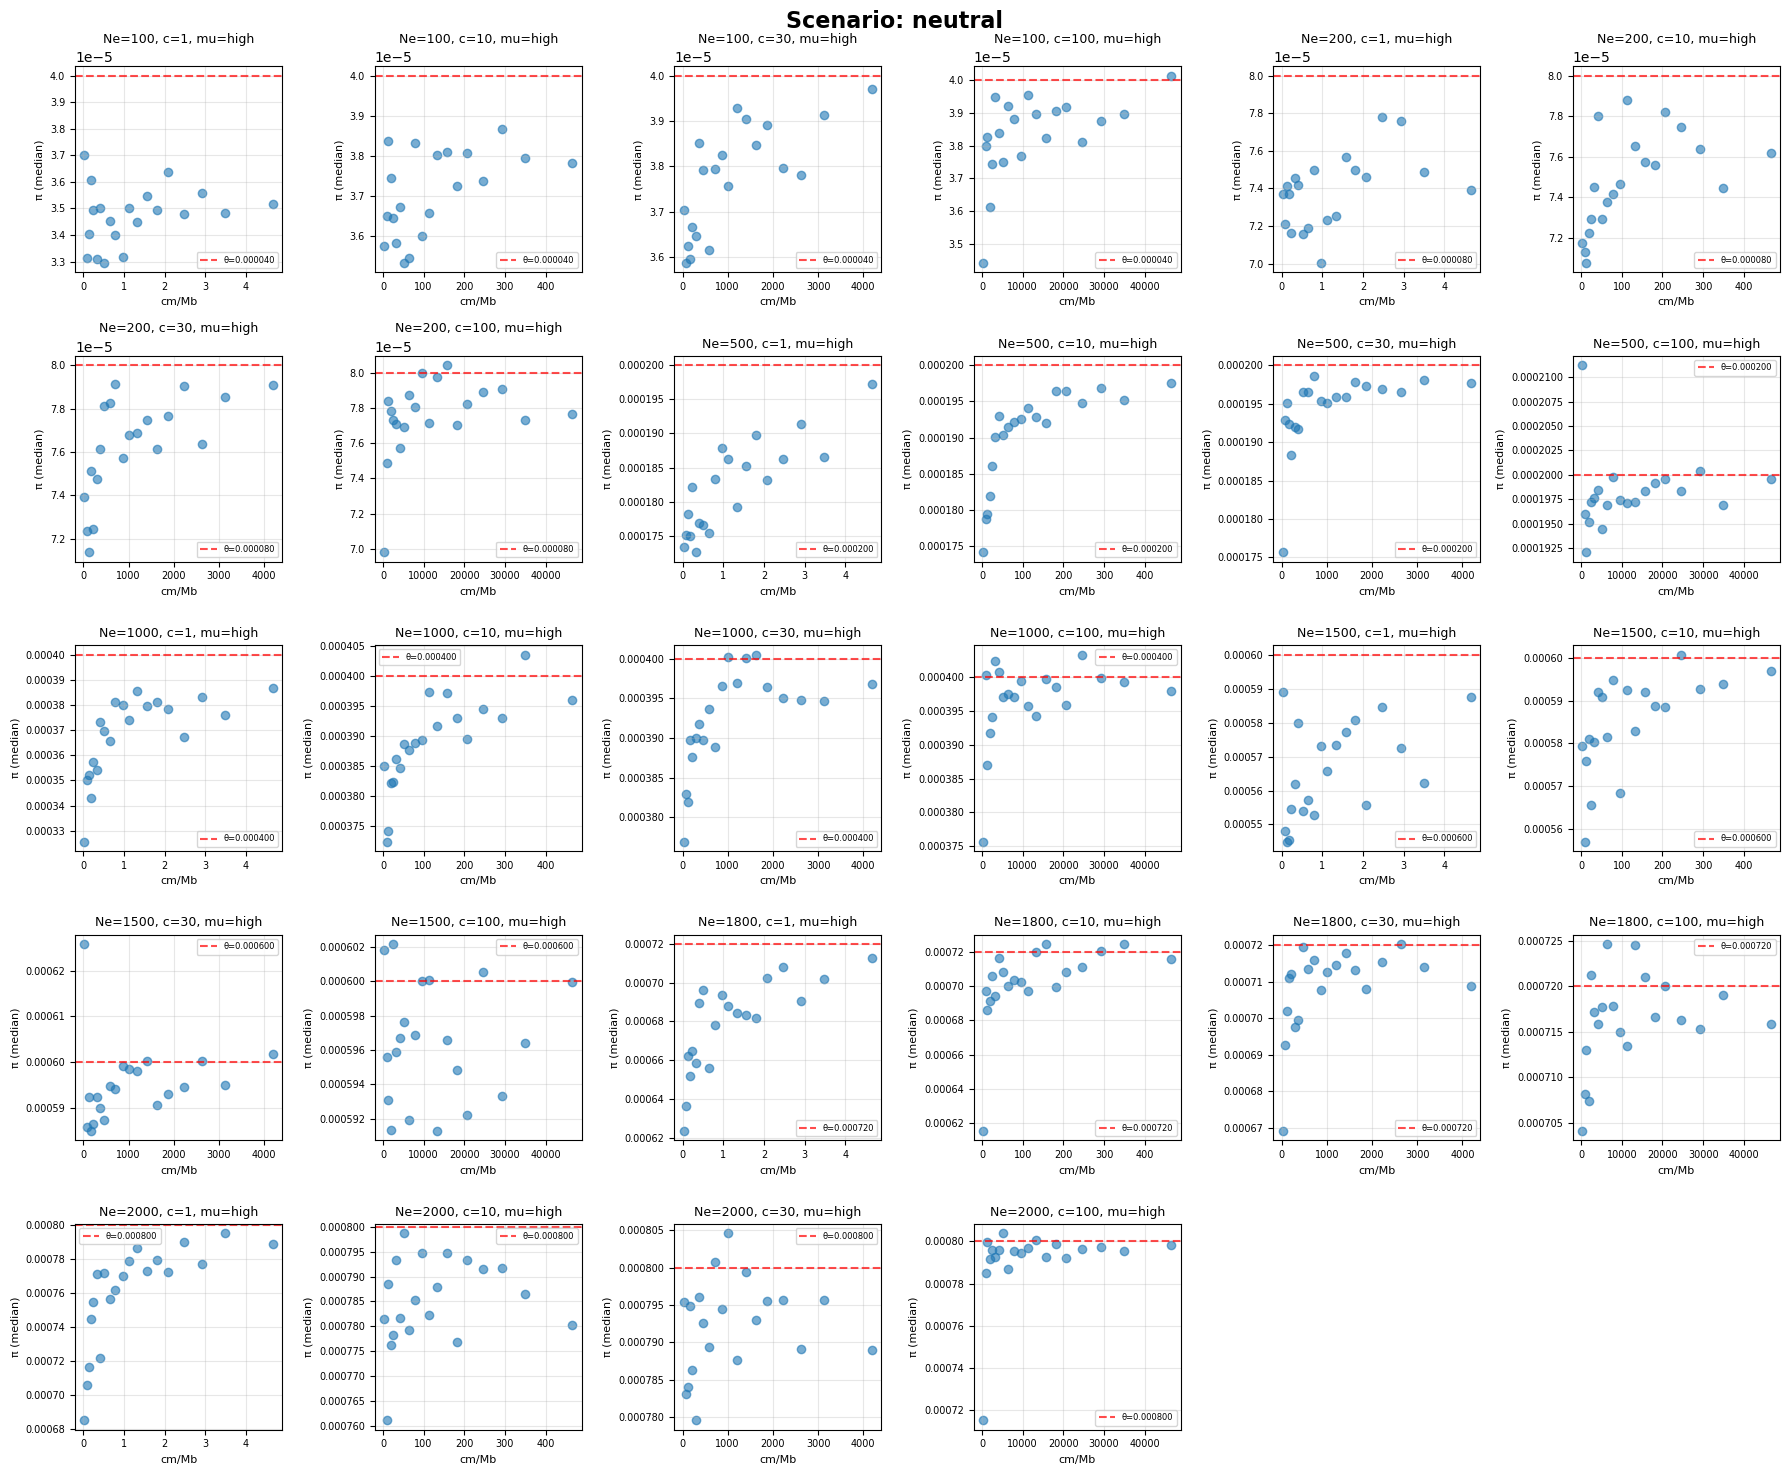

In [4]:
# Plot each scenario separately
nes_plot = [100,200,500,1000,1500,1800,2000]
scenarios_plot = ['bgs', 'hh', 'neutral']
ss_plot = [0.01]
cs_plot = [1,10,30,100]
mu_keys_plot = ['high']

# Get mu value from first row (assuming all same)
mu = concat['mu'].iloc[0]

# Helper function to compare tuples with NaN
def tuples_equal(t1, t2):
    if len(t1) != len(t2):
        return False
    for a, b in zip(t1, t2):
        if pd.isna(a) and pd.isna(b):
            continue
        elif a != b:
            return False
    return True

for scenario in scenarios_plot:
    # Generate all combinations for this scenario
    scenario_combinations = []
    for ne in nes_plot:
        for c in cs_plot:
            for mu_key in mu_keys_plot:
                if scenario == 'hh':
                    for s in ss_plot:
                        scenario_combinations.append((ne, s, mu_key, c))
                else:
                    scenario_combinations.append((ne, np.nan, mu_key, c))
    
    n_combinations = len(scenario_combinations)
    
    # Calculate grid size dynamically
    ncols = int(np.ceil(np.sqrt(n_combinations)))
    nrows = int(np.ceil(n_combinations / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
    
    # Handle case where there's only one subplot
    if n_combinations == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Filter existing data for this scenario and create lookup dict
    scenario_data = concat[concat['scenario'] == scenario]
    scenario_grouped = scenario_data.groupby(['ne', 's', 'mu_key', 'c'], dropna=False)
    existing_groups = {name: group for name, group in scenario_grouped}
    
    for idx, combo in enumerate(scenario_combinations):
        ax = axes[idx]
        ne, s, mu_key, c = combo
        
        # Find matching group (handling NaN comparison)
        group = None
        for key, grp in existing_groups.items():
            if tuples_equal(combo, key):
                group = grp
                break
        
        # Check if this combination exists in the data
        if group is not None:
            ax.scatter(group['cm_mb'], group['pi'], alpha=0.6)
        else:
            # Empty plot with message
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
        
        # Add neutral expectation line (θ = 4*Ne*mu)
        theta =  4 * ne * 1e-7
        ax.axhline(y=theta, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label=f'θ={theta:.6f}')
        
        s_str = f', s={s}' if pd.notna(s) else ''
        ax.set_title(f'Ne={ne}{s_str}, c={c}, mu={mu_key}', fontsize=9)
        ax.set_xlabel('cm/Mb', fontsize=8)
        ax.set_ylabel('π (median)', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6)
    
    # Hide unused subplots
    for idx in range(n_combinations, len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle(f'Scenario: {scenario}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

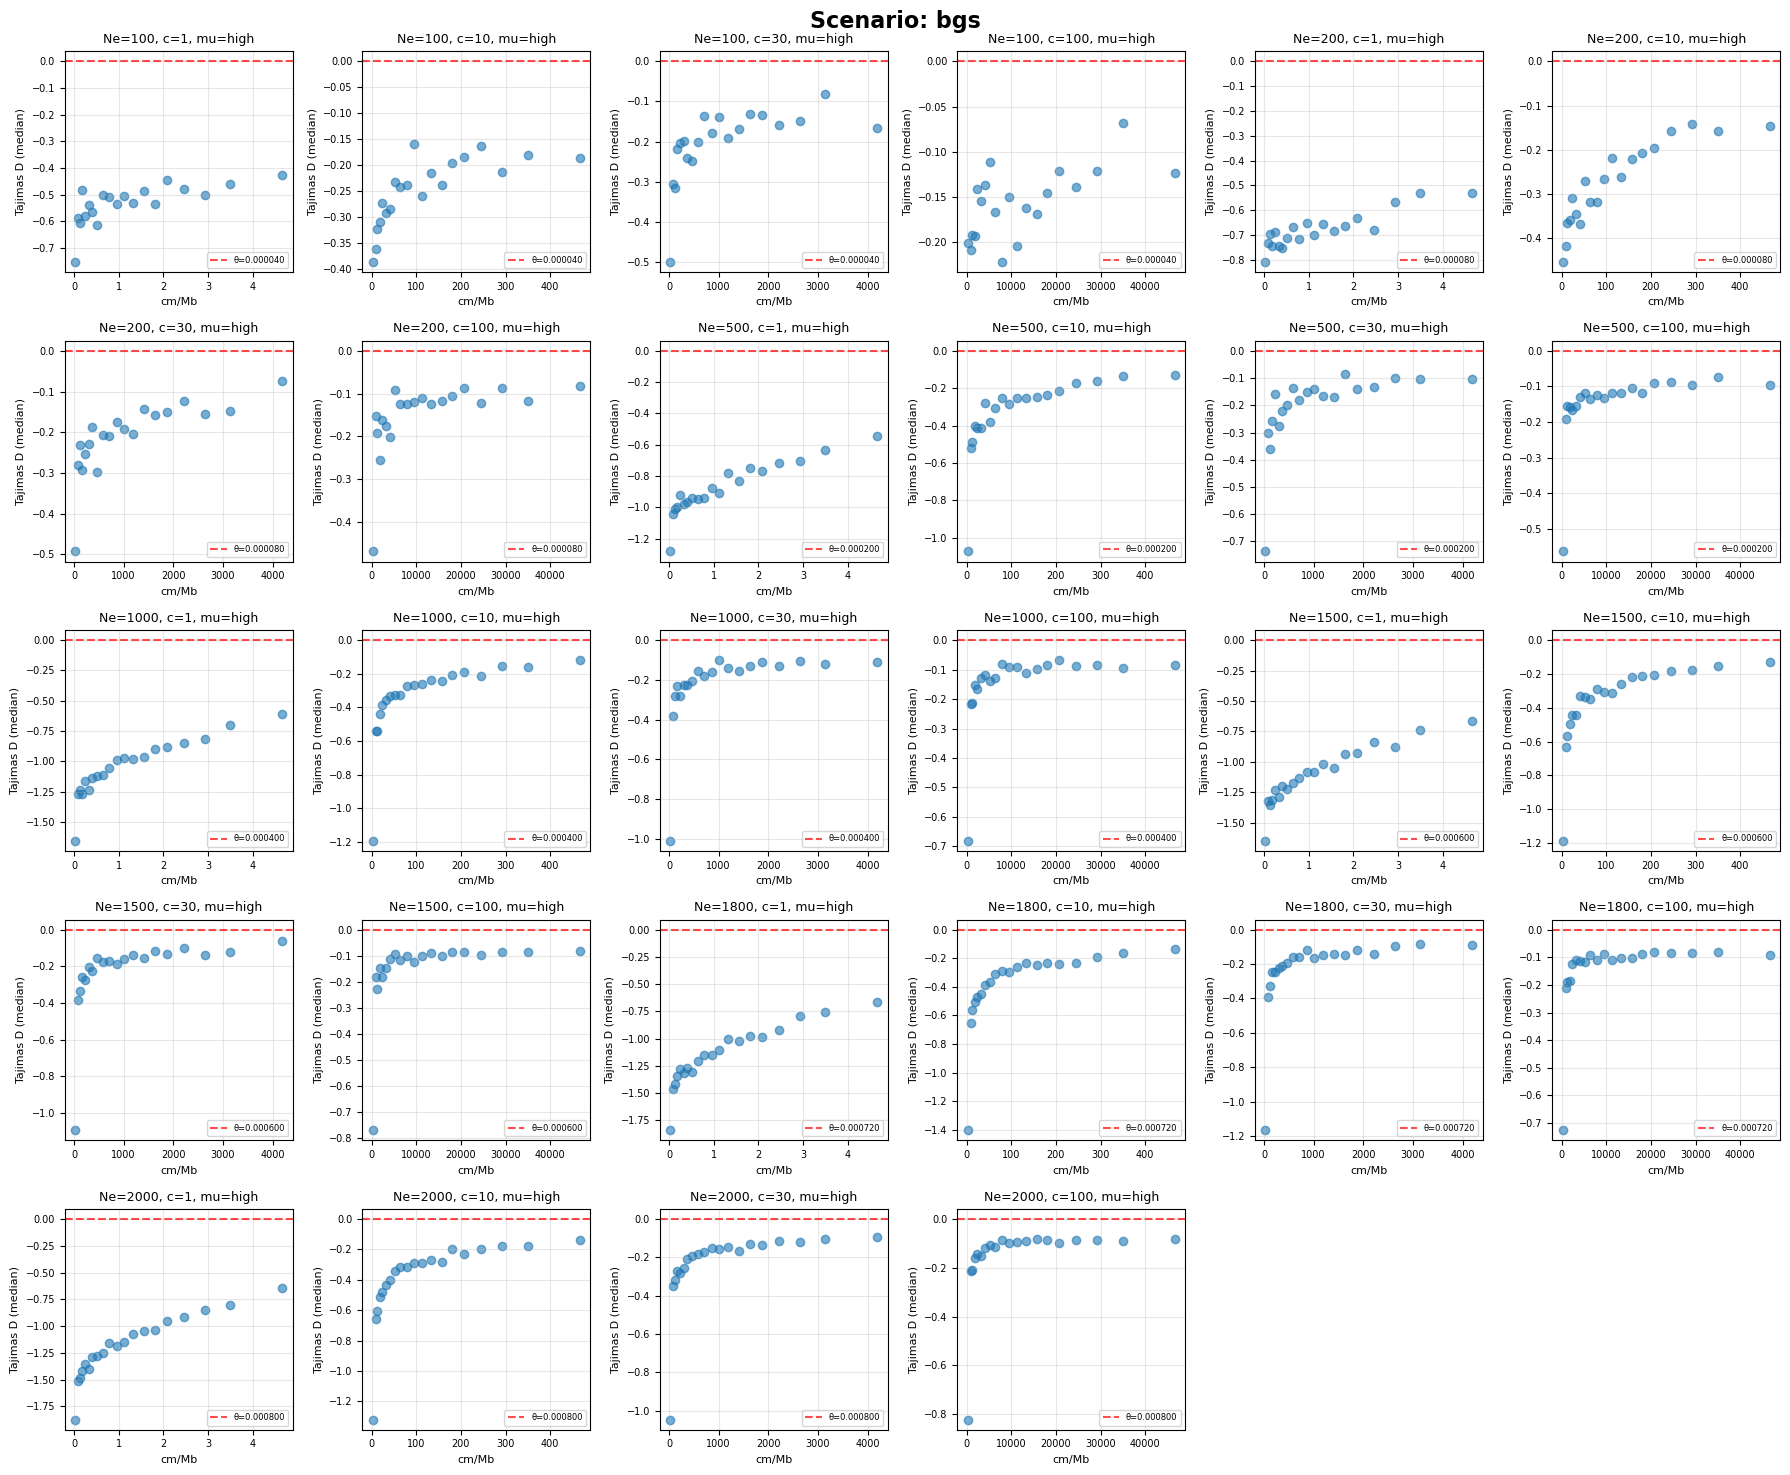

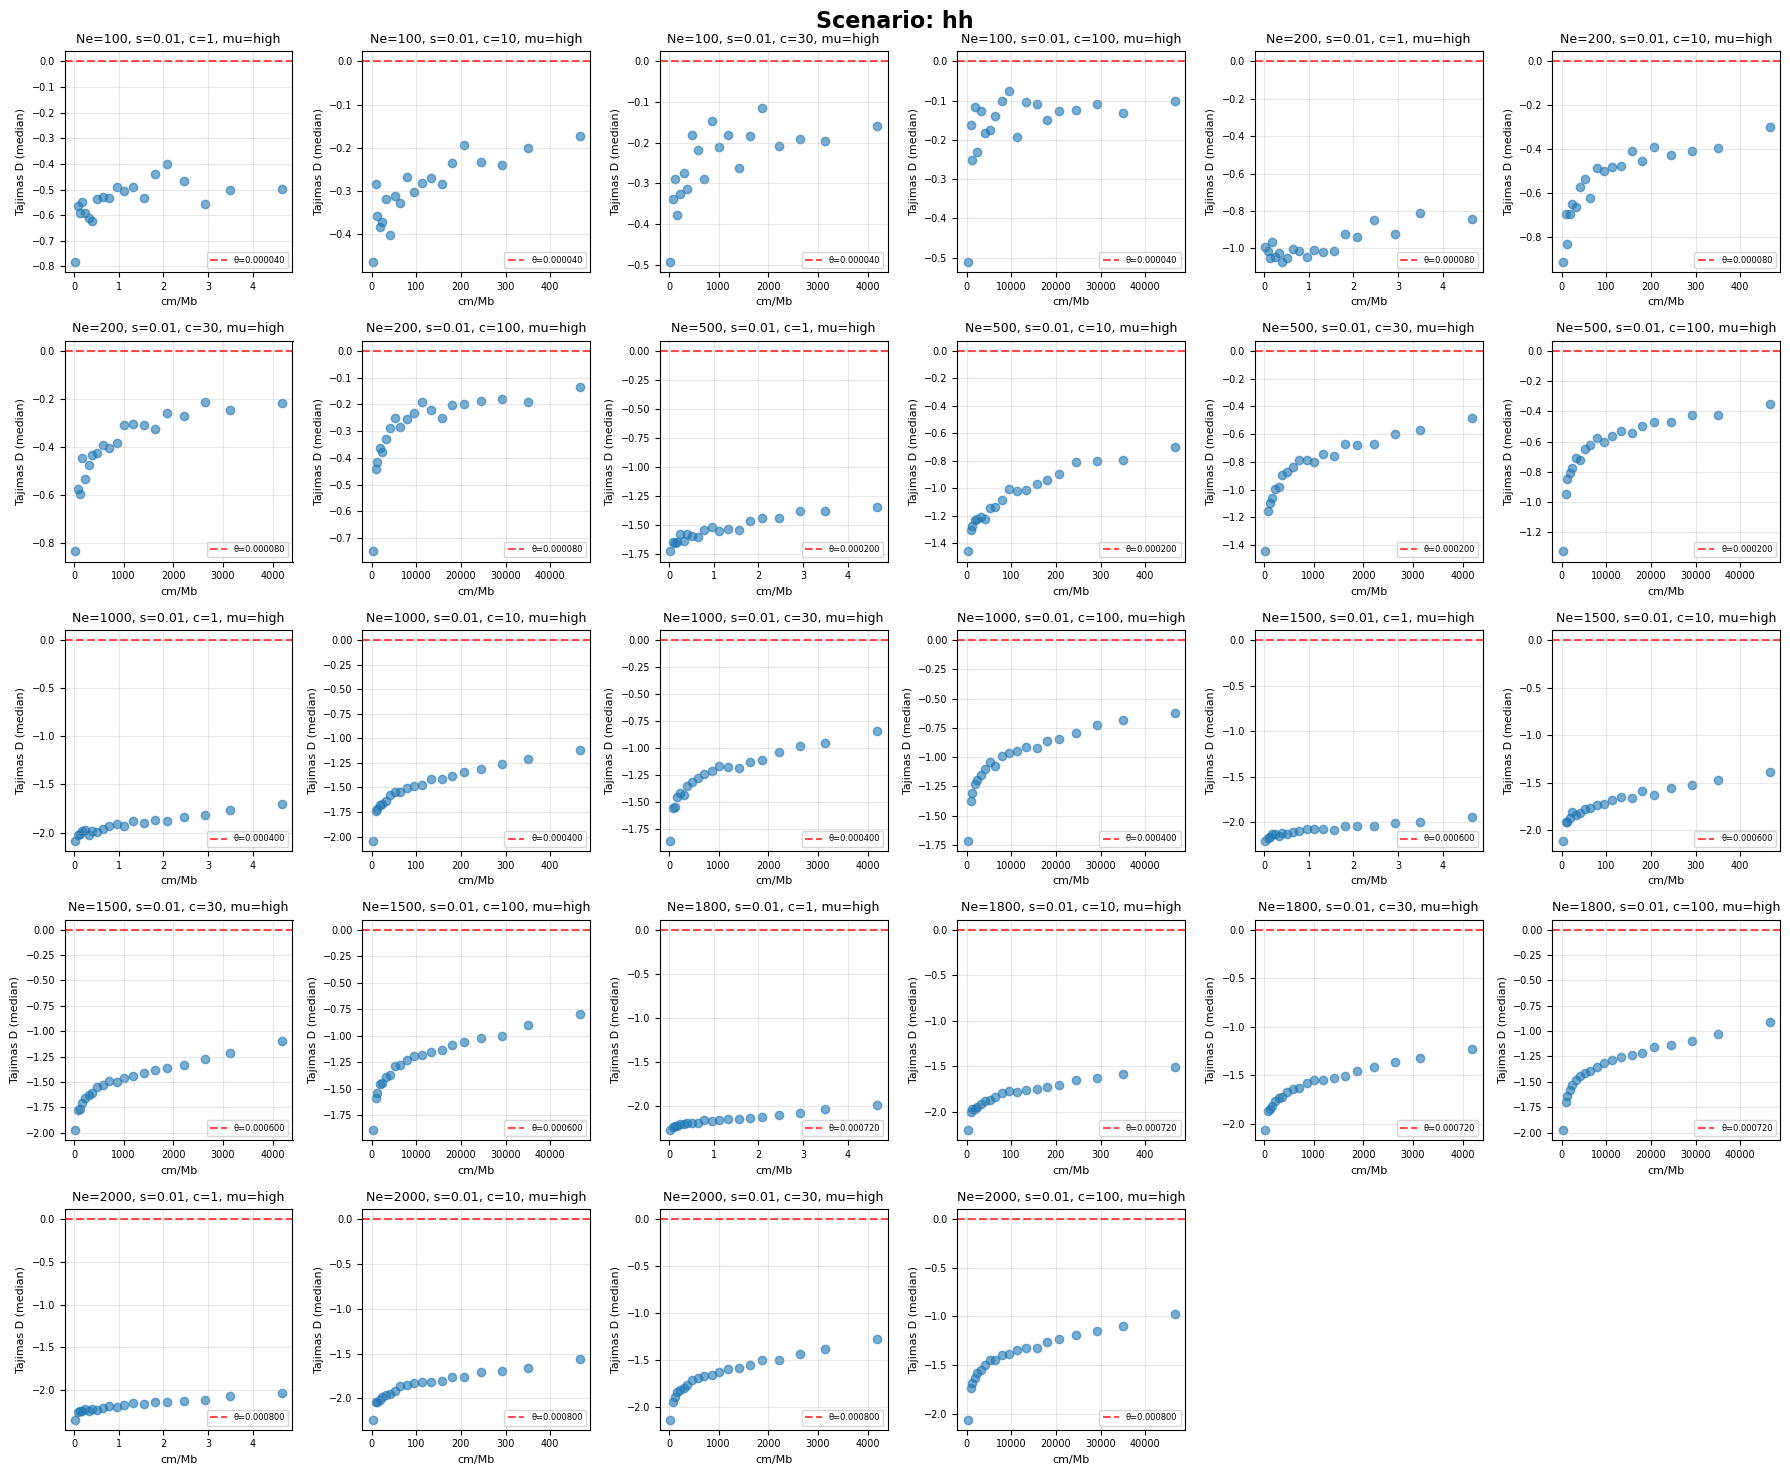

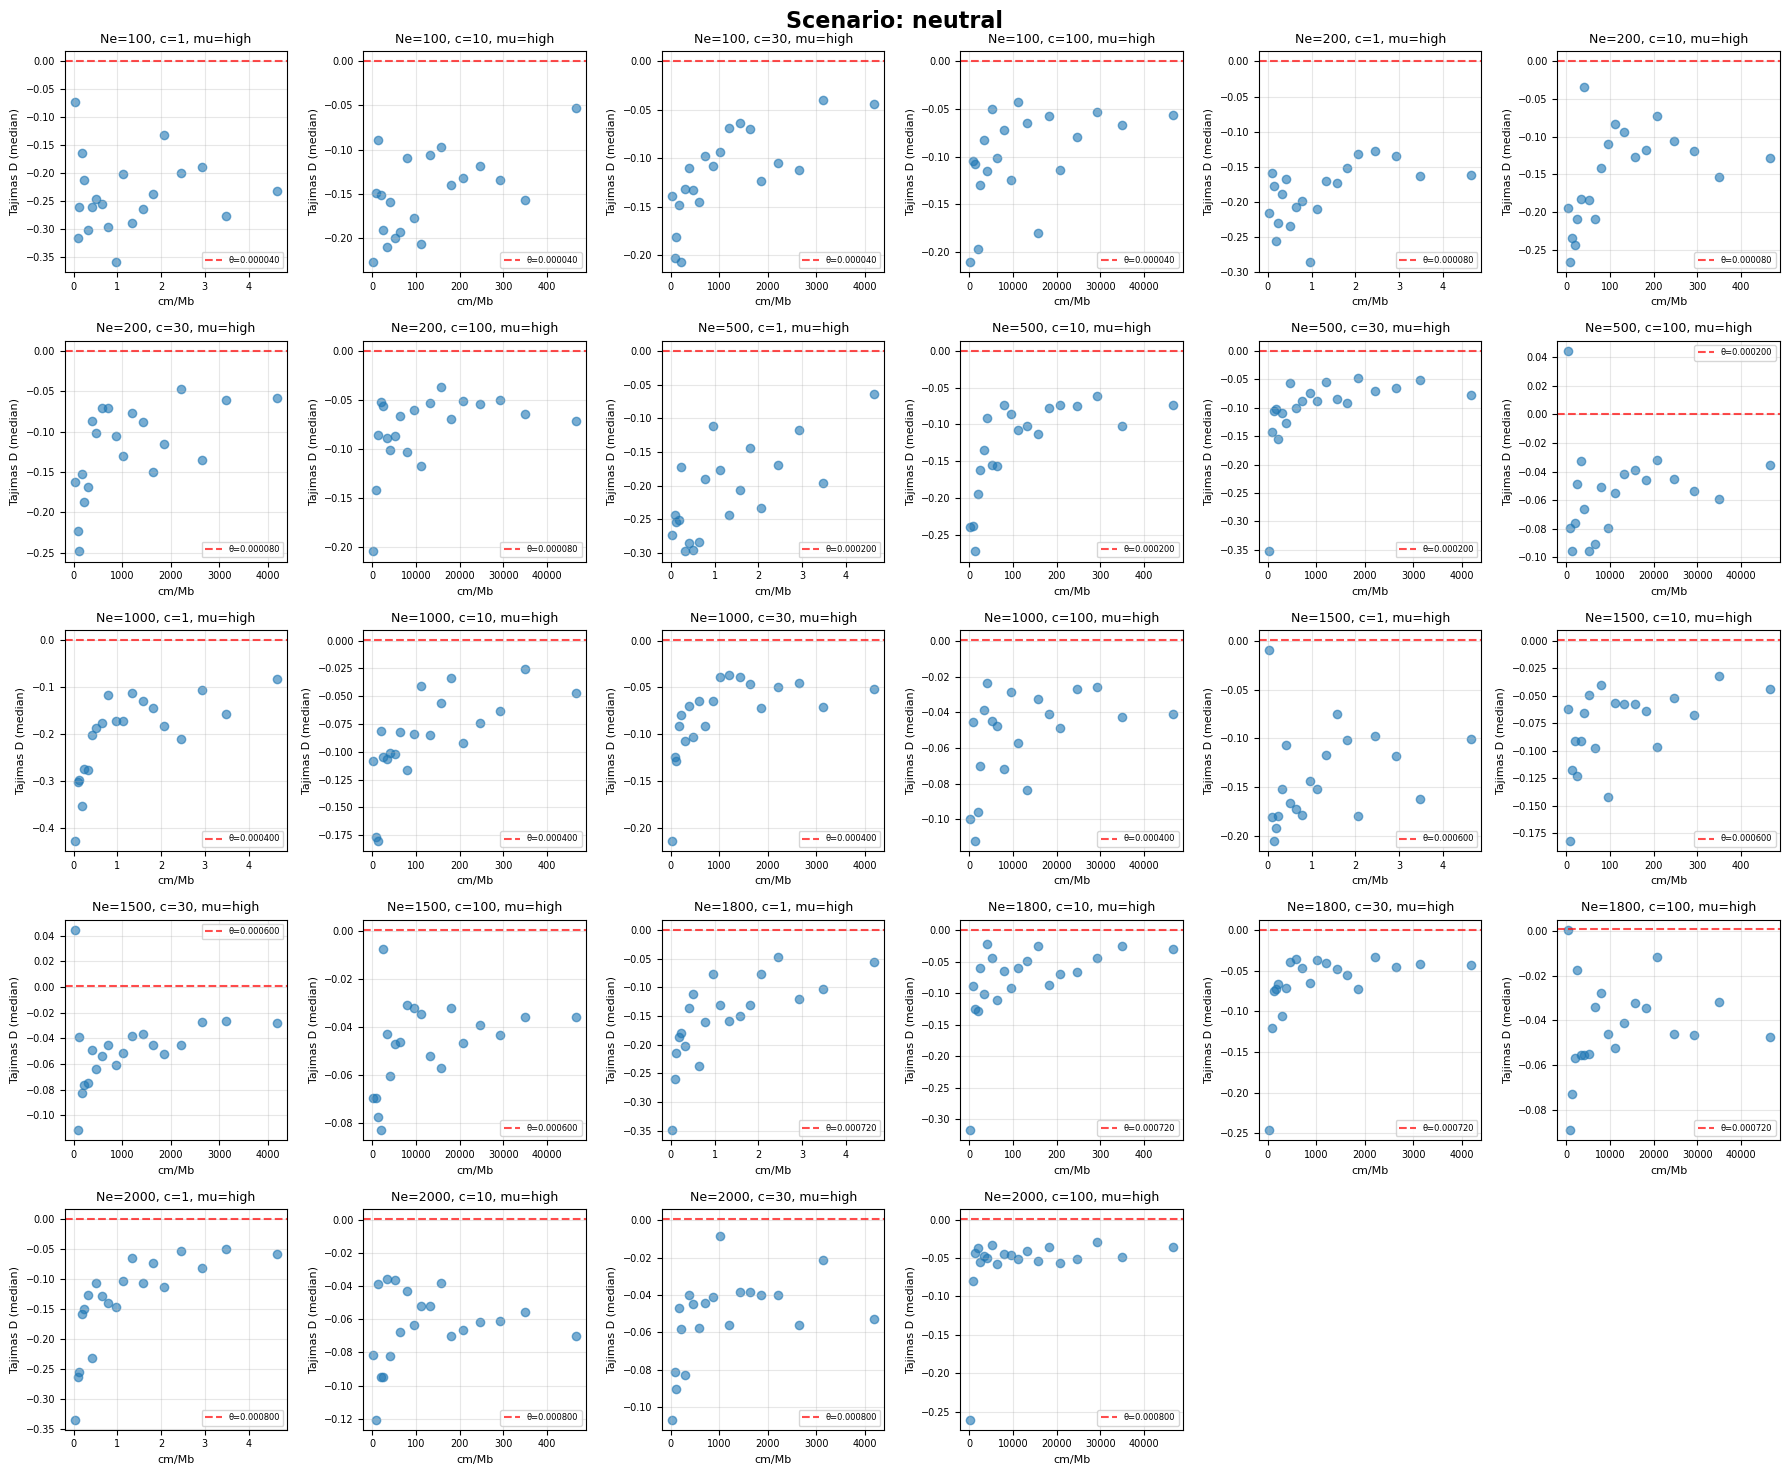

In [5]:
# Plot each scenario separately
nes_plot = [100,200,500,1000,1500,1800,2000]
scenarios_plot = ['bgs', 'hh', 'neutral']
ss_plot = [0.01]
cs_plot = [1,10,30,100]
mu_keys_plot = ['high']

# Get mu value from first row (assuming all same)
mu = concat['mu'].iloc[0]

# Helper function to compare tuples with NaN
def tuples_equal(t1, t2):
    if len(t1) != len(t2):
        return False
    for a, b in zip(t1, t2):
        if pd.isna(a) and pd.isna(b):
            continue
        elif a != b:
            return False
    return True

for scenario in scenarios_plot:
    # Generate all combinations for this scenario
    scenario_combinations = []
    for ne in nes_plot:
        for c in cs_plot:
            for mu_key in mu_keys_plot:
                if scenario == 'hh':
                    for s in ss_plot:
                        scenario_combinations.append((ne, s, mu_key, c))
                else:
                    scenario_combinations.append((ne, np.nan, mu_key, c))
    
    n_combinations = len(scenario_combinations)
    
    # Calculate grid size dynamically
    ncols = int(np.ceil(np.sqrt(n_combinations)))
    nrows = int(np.ceil(n_combinations / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
    
    # Handle case where there's only one subplot
    if n_combinations == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Filter existing data for this scenario and create lookup dict
    scenario_data = concat[concat['scenario'] == scenario]
    scenario_grouped = scenario_data.groupby(['ne', 's', 'mu_key', 'c'], dropna=False)
    existing_groups = {name: group for name, group in scenario_grouped}
    
    for idx, combo in enumerate(scenario_combinations):
        ax = axes[idx]
        ne, s, mu_key, c = combo
        
        # Find matching group (handling NaN comparison)
        group = None
        for key, grp in existing_groups.items():
            if tuples_equal(combo, key):
                group = grp
                break
        
        # Check if this combination exists in the data
        if group is not None:
            ax.scatter(group['cm_mb'], group['taj_d'], alpha=0.6)
        else:
            # Empty plot with message
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
        
        # Add neutral expectation line (θ = 4*Ne*mu)
        theta =  4 * ne * 1e-7
        ax.axhline(y=theta, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label=f'θ={theta:.6f}')
        
        s_str = f', s={s}' if pd.notna(s) else ''
        ax.set_title(f'Ne={ne}{s_str}, c={c}, mu={mu_key}', fontsize=9)
        ax.set_xlabel('cm/Mb', fontsize=8)
        ax.set_ylabel('Tajimas D (median)', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6)
    
    # Hide unused subplots
    for idx in range(n_combinations, len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle(f'Scenario: {scenario}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Relationship with Ne


### Relative reduction

C = 1 

In [6]:
# fixed_parameters = concat.loc[concat['c']==1]
# pi_0 = fixed_parameters[fixed_parameters['index'] == 0][['scenario', 'ne', 's', 'pi']].rename(columns={'pi': 'pi_0'})
# pi_19 = fixed_parameters[fixed_parameters['index'] == 19][['scenario', 'ne', 's', 'pi']].rename(columns={'pi': 'pi_19'})

# relative_reduction = pi_19.merge(pi_0, on=['scenario', 'ne', 's'])
# relative_reduction['relative_reduction'] = (relative_reduction['pi_19'] - relative_reduction['pi_0'])/relative_reduction['pi_19']
# sns.lmplot(x="ne", y="relative_reduction", data=relative_reduction, hue='scenario')

C = 10

In [7]:
# fixed_parameters = concat.loc[concat['c']==10]
# pi_0 = fixed_parameters[fixed_parameters['index'] == 0][['scenario', 'ne', 's', 'pi']].rename(columns={'pi': 'pi_0'})
# pi_19 = fixed_parameters[fixed_parameters['index'] == 19][['scenario', 'ne', 's', 'pi']].rename(columns={'pi': 'pi_19'})
# relative_reduction = pi_19.merge(pi_0, on=['scenario', 'ne', 's'])
# relative_reduction['relative_reduction'] = (relative_reduction['pi_19'] - relative_reduction['pi_0'])/relative_reduction['pi_19']
# sns.lmplot(x="ne", y="relative_reduction", data=relative_reduction, hue='scenario')

c = 30

In [8]:
# fixed_parameters = concat.loc[concat['c']==30]
# pi_0 = fixed_parameters[fixed_parameters['index'] == 0][['scenario', 'ne', 's', 'pi']].rename(columns={'pi': 'pi_0'})
# pi_19 = fixed_parameters[fixed_parameters['index'] == 19][['scenario', 'ne', 's', 'pi']].rename(columns={'pi': 'pi_19'})
# relative_reduction = pi_19.merge(pi_0, on=['scenario', 'ne', 's'])
# relative_reduction['relative_reduction'] = (relative_reduction['pi_19'] - relative_reduction['pi_0'])/relative_reduction['pi_19']
# sns.lmplot(x="ne", y="relative_reduction", data=relative_reduction, hue='scenario')

C = 100

In [9]:
# fixed_parameters = concat.loc[concat['c']==100]
# pi_0 = fixed_parameters[fixed_parameters['index'] == 0][['scenario', 'ne', 's', 'pi']].rename(columns={'pi': 'pi_0'})
# pi_19 = fixed_parameters[fixed_parameters['index'] == 19][['scenario', 'ne', 's', 'pi']].rename(columns={'pi': 'pi_19'})
# relative_reduction = pi_19.merge(pi_0, on=['scenario', 'ne', 's'])
# relative_reduction['relative_reduction'] = (relative_reduction['pi_19'] - relative_reduction['pi_0'])/relative_reduction['pi_19']
# sns.lmplot(x="ne", y="relative_reduction", data=relative_reduction, hue='scenario')

#### 4 Subplots - One for each c value

In [10]:
# Prepare data for all c values
cs_values = [1, 10, 30, 100]
all_data = []

for c_val in cs_values:
    fixed_parameters = concat.loc[concat['c'] == c_val]
    pi_0 = fixed_parameters[fixed_parameters['index'] == 0][['scenario', 'ne', 's',
'pi']].rename(columns={'pi': 'pi_0'})
    pi_19 = fixed_parameters[fixed_parameters['index'] == 19][['scenario', 'ne', 's',
'pi']].rename(columns={'pi': 'pi_19'})

    relative_reduction = pi_19.merge(pi_0, on=['scenario', 'ne', 's'])
    relative_reduction['relative_reduction'] = (relative_reduction['pi_19'] -
relative_reduction['pi_0']) / relative_reduction['pi_19']
    relative_reduction['c'] = c_val
    all_data.append(relative_reduction)

# Combine all data
combined_data = pd.concat(all_data, ignore_index=True)

# Create a combined scenario-c label for better legend
combined_data['scenario_c'] = combined_data['scenario'] + ' (c=' + combined_data['c'].astype(str) + ')'

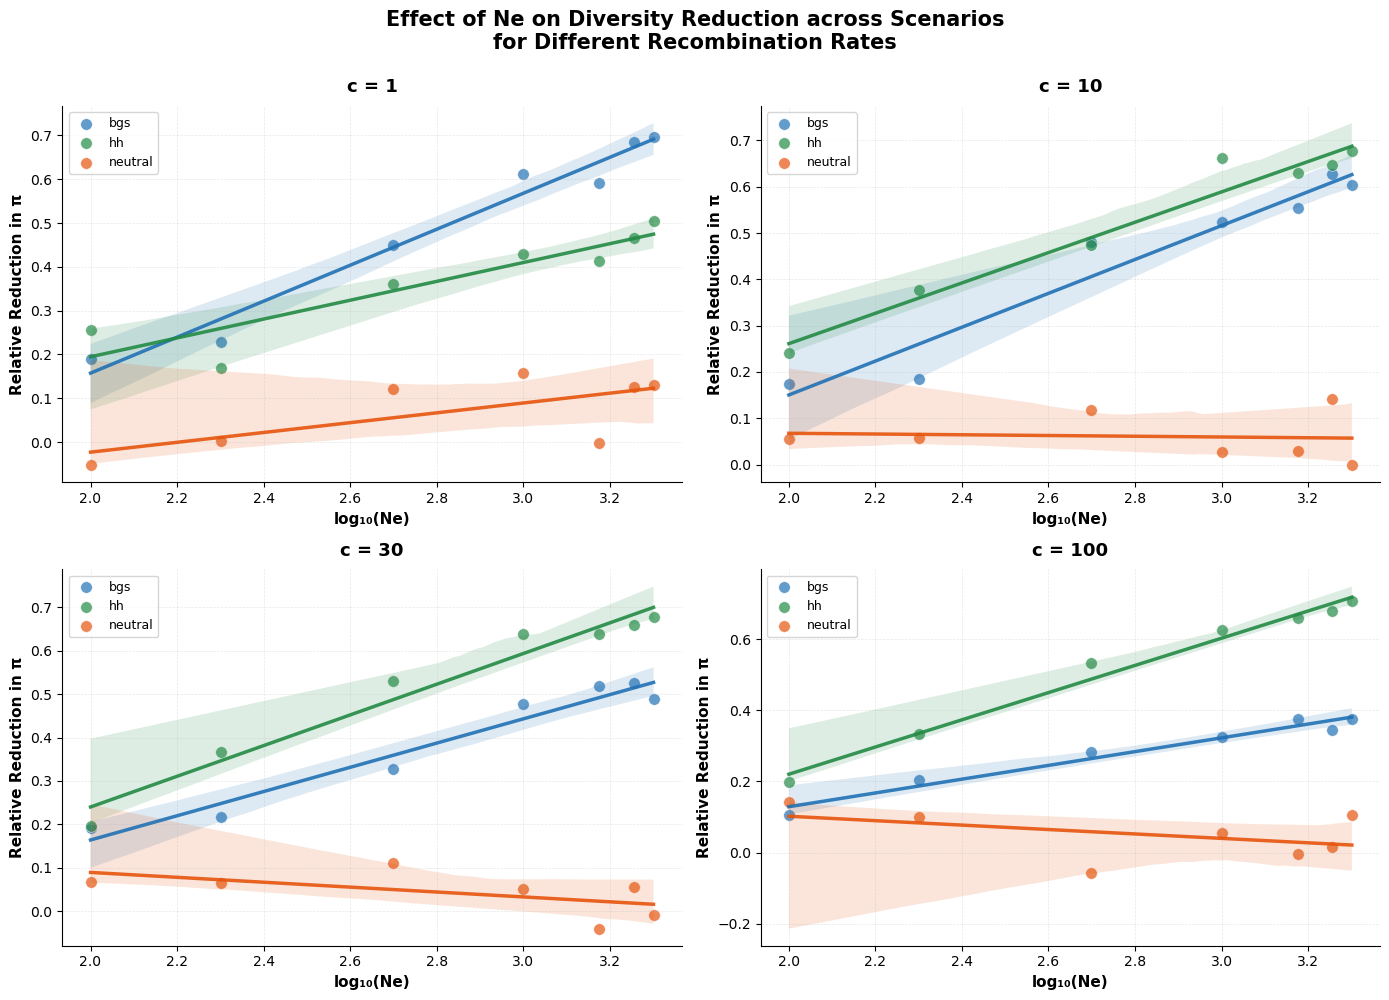

In [11]:
# Create a log10(Ne) column for plotting
combined_data['log10_ne'] = np.log10(combined_data['ne'])

# Create a 2x2 subplot for each c value
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Define distinct colors for each scenario
scenario_colors = {
    'bgs': '#2171b5',      # Blue
    'hh': '#238b45',       # Green
    'neutral': '#e6550d'   # Orange
}

# Create x values for the reference line
# x_ref = np.linspace(combined_data['log10_ne'].min(), combined_data['log10_ne'].max(), 100)
# y_ref = -0.01556 + 0.08914697 * x_ref

# Plot each c value in a separate subplot
for idx, c_val in enumerate(cs_values):
    ax = axes[idx]
    
    # Filter data for this c value
    c_data = combined_data[combined_data['c'] == c_val]
    
    # Plot each scenario
    for scenario in ['bgs', 'hh', 'neutral']:
        scenario_data = c_data[c_data['scenario'] == scenario]
        
        if len(scenario_data) > 0:
            # Plot with regression line
            sns.regplot(
                data=scenario_data,
                x='log10_ne',
                y='relative_reduction',
                ax=ax,
                color=scenario_colors[scenario],
                label=scenario,
                scatter_kws={'alpha': 0.7, 's': 70, 'edgecolors': 'white', 'linewidths': 0.5},
                line_kws={'linewidth': 2.5, 'alpha': 0.9},
                ci=95
            )
    
    # Add reference line
    #ax.plot(x_ref, y_ref, 'k--', linewidth=2, label='observed', alpha=0.8)
    
    # Customize each subplot
    ax.set_xlabel('log₁₀(Ne)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Relative Reduction in π', fontsize=11, fontweight='bold')
    ax.set_title(f'c = {c_val}', fontsize=13, fontweight='bold', pad=10)
    ax.legend(frameon=True, fontsize=9, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Overall title
fig.suptitle('Effect of Ne on Diversity Reduction across Scenarios\nfor Different Recombination Rates', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Tajimas D

In [12]:
#fixed_parameters

In [13]:
# Prepare data for all c values
cs_values = [1, 10, 30, 100]
all_data = []

for c_val in cs_values:
    fixed_parameters = concat.loc[concat['c'] == c_val]
    taj_d_0 = fixed_parameters[fixed_parameters['index'] == 0][['scenario', 'ne', 's',
'taj_d']].rename(columns={'taj_d': 'taj_d_0'})
    taj_d_19 = fixed_parameters[fixed_parameters['index'] == 19][['scenario', 'ne', 's',
'taj_d']].rename(columns={'taj_d': 'taj_d_19'})

    relative_reduction = taj_d_19.merge(taj_d_0, on=['scenario', 'ne', 's'])
    relative_reduction['relative_reduction'] = (abs(relative_reduction['taj_d_0']) -
abs(relative_reduction['taj_d_19'])) / relative_reduction['taj_d_0']
    relative_reduction['c'] = c_val
    all_data.append(relative_reduction)

# Combine all data
combined_data = pd.concat(all_data, ignore_index=True)

# Create a combined scenario-c label for better legend
combined_data['scenario_c'] = combined_data['scenario'] + ' (c=' + combined_data['c'].astype(str) + ')'

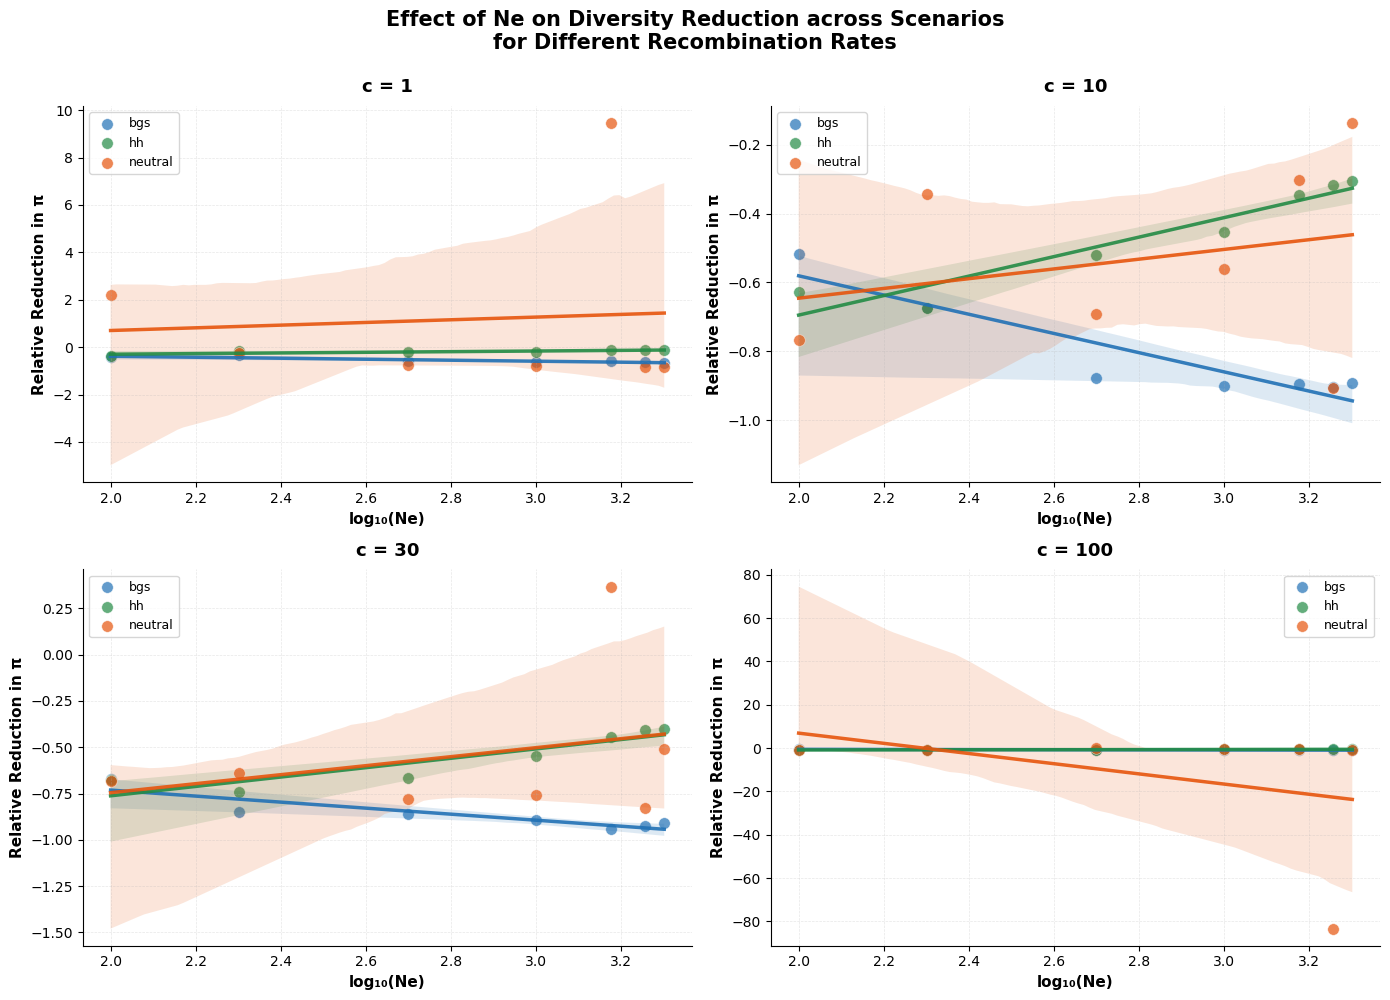

In [14]:
# Create a log10(Ne) column for plotting
combined_data['log10_ne'] = np.log10(combined_data['ne'])

# Create a 2x2 subplot for each c value
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Define distinct colors for each scenario
scenario_colors = {
    'bgs': '#2171b5',      # Blue
    'hh': '#238b45',       # Green
    'neutral': '#e6550d'   # Orange
}

# Create x values for the reference line
# x_ref = np.linspace(combined_data['log10_ne'].min(), combined_data['log10_ne'].max(), 100)
# y_ref = -0.01556 + 0.08914697 * x_ref

# Plot each c value in a separate subplot
for idx, c_val in enumerate(cs_values):
    ax = axes[idx]
    
    # Filter data for this c value
    c_data = combined_data[combined_data['c'] == c_val]
    
    # Plot each scenario
    for scenario in ['bgs', 'hh', 'neutral']:
        scenario_data = c_data[c_data['scenario'] == scenario]
        
        if len(scenario_data) > 0:
            # Plot with regression line
            sns.regplot(
                data=scenario_data,
                x='log10_ne',
                y='relative_reduction',
                ax=ax,
                color=scenario_colors[scenario],
                label=scenario,
                scatter_kws={'alpha': 0.7, 's': 70, 'edgecolors': 'white', 'linewidths': 0.5},
                line_kws={'linewidth': 2.5, 'alpha': 0.9},
                ci=95
            )
    
    # Add reference line
    #ax.plot(x_ref, y_ref, 'k--', linewidth=2, label='observed', alpha=0.8)
    
    # Customize each subplot
    ax.set_xlabel('log₁₀(Ne)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Relative Reduction in π', fontsize=11, fontweight='bold')
    ax.set_title(f'c = {c_val}', fontsize=13, fontweight='bold', pad=10)
    ax.legend(frameon=True, fontsize=9, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Overall title
fig.suptitle('Effect of Ne on Diversity Reduction across Scenarios\nfor Different Recombination Rates', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()